In [57]:
import sys
from pathlib import Path

# Add the src directory to Python path
sys.path.insert(0, str(Path().resolve().parent / 'src'))

from config import EXTERNAL_DATA_DIR, INTERIM_DATA_DIR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from datetime import datetime, timedelta

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [58]:
def get_clob_token_ids(market_id):
    """
    Fetch CLOB token IDs from a Polymarket market ID.
    Returns (yes_token_id, no_token_id, market_question)
    """
    url = f"https://gamma-api.polymarket.com/markets/{market_id}"
    response = requests.get(url)
    
    if response.status_code != 200:
        raise ValueError(f"Failed to fetch market {market_id}: {response.status_code}")
    
    data = response.json()
    clob_ids = data.get('clobTokenIds', [])
    
    # Handle case where clobTokenIds might be a JSON string
    if isinstance(clob_ids, str):
        import json
        clob_ids = json.loads(clob_ids)
    
    if len(clob_ids) < 2:
        raise ValueError(f"Market {market_id} doesn't have CLOB token IDs")
    
    return clob_ids[0], clob_ids[1], data.get('question', 'Unknown')

def fetch_historical_prices(clob_token_id, start_ts, end_ts):
    """
    Fetches historical prices from Polymarket using CLOB token ID.
    """
    url = "https://clob.polymarket.com/prices-history"
    params = {
        "market": clob_token_id,
        "startTs": int(start_ts),
        "endTs": int(end_ts),
        "fidelity": 60  # 60-minute fidelity
    }
    
    response = requests.get(url, params=params)
    data = response.json().get('history', [])
    
    if not data:
        return pd.Series(dtype=float)
    
    df = pd.DataFrame(data)
    df['datetime'] = pd.to_datetime(df['t'], unit='s')
    df.set_index('datetime', inplace=True)
    return df['p'].astype(float)

In [59]:
def build_synthetic_basket_old(target_market_id, input_market_ids, days=7):
    """
    Build a synthetic basket to replicate a target market using input markets.
    
    Args:
        target_market_id: Polymarket market ID for the target
        input_market_ids: List of Polymarket market IDs for inputs
        days: Number of days of historical data to use (default: 7)
    
    Returns:
        dict with weights, market info, R-squared, and dataframe
    """
    # Set time window
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days)
    start_ts = start_date.timestamp()
    end_ts = end_date.timestamp()
    
    print(f"Time window: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print("=" * 60)

    # 1. Fetch CLOB token IDs and market info
    print(f"\n[1/4] Fetching market metadata...")
    target_clob, _, target_question = get_clob_token_ids(target_market_id)
    print(f"Target: {target_question}")
    
    input_info = []
    for market_id in input_market_ids:
        clob_id, _, question = get_clob_token_ids(market_id)
        input_info.append({'market_id': market_id, 'clob_id': clob_id, 'question': question})
        print(f"Input:  {question}")

    # 2. Fetch historical prices
    print(f"\n[2/4] Fetching price histories...")
    target_series = fetch_historical_prices(target_clob, start_ts, end_ts)
    target_series.name = 'Target'
    print(f"Target: {len(target_series)} data points")
    
    input_series_list = []
    for info in input_info:
        series = fetch_historical_prices(info['clob_id'], start_ts, end_ts)
        series.name = info['question'][:40] + '...' if len(info['question']) > 40 else info['question']
        input_series_list.append(series)
        print(f"Input:  {len(series)} data points - {info['question'][:50]}")

    # 3. Align and resample data
    print(f"\n[3/4] Aligning time series data...")
    
    # Resample each series INDIVIDUALLY to 5-minute bars first (close price of each bar)
    # This aligns irregular market ticks to a regular time grid
    print("Resampling each series to 5-minute bars...")
    target_resampled = target_series.resample('5min').ffill()
    print(f"Target: {len(target_series)} ticks → {len(target_resampled)} bars")
    
    input_resampled_list = []
    for i, series in enumerate(input_series_list):
        resampled = series.resample('5min').ffill()
        resampled.name = series.name
        input_resampled_list.append(resampled)
        print(f"Input {i+1}: {len(series)} ticks → {len(resampled)} bars")
    
    # Now concat the resampled series - they're all on the same time grid
    df = pd.concat([target_resampled] + input_resampled_list, axis=1, sort=True)
    print(f"\nAfter concat: {len(df)} rows")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    
    # Forward fill any remaining gaps
    df = df.ffill()
    
    # Drop rows with any NaN values
    initial_len = len(df)
    df = df.dropna()
    print(f"After dropna: {len(df)} aligned observations ({initial_len - len(df)} rows dropped)")
    
    if df.empty:
        print("\nDEBUG: DataFrame is empty after alignment!")
        raise ValueError("No overlapping time-series data after alignment.")

    # 4. Solve linear regression (Least Squares)
    print(f"\n[4/4] Solving for optimal weights...")
    y = df['Target'].values
    X = df.drop(columns=['Target']).values
    
    # Standard least squares: minimize ||y - Xw||^2
    weights, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
    
    # Calculate synthetic price
    df['Synthetic'] = X @ weights
    
    # Calculate R-squared
    ss_res = np.sum((y - df['Synthetic'].values)**2)
    ss_tot = np.sum((y - y.mean())**2)
    r_squared = 1 - (ss_res / ss_tot)

    # 5. Display results
    print("\n" + "=" * 60)
    print("OPTIMAL BASKET WEIGHTS")
    print("=" * 60)
    for i, info in enumerate(input_info):
        print(f"{weights[i]:+.4f}  | {info['question']}")
    print(f"\nR² (fit quality): {r_squared:.4f}")
    print(f"Mean Absolute Error: {np.mean(np.abs(y - df['Synthetic'].values)):.4f}")

    # 6. Visualize
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['Target'], label='Real Target Price', color='blue', linewidth=2)
    plt.plot(df.index, df['Synthetic'], label='Synthetic Basket Price', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Synthetic Basket vs Target Market\n{target_question}', fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel('Probability', fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Return results
    return {
        'weights': weights,
        'r_squared': r_squared,
        'target_question': target_question,
        'input_markets': [info['question'] for info in input_info],
        'dataframe': df
    }

In [60]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler

# ==========================================
# IMPROVED SOLVER HELPER FUNCTIONS
# ==========================================

def solve_ols(X, y):
    """Standard Ordinary Least Squares (No regularization)."""
    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)
    print(f"  Intercept: {model.intercept_:.4f}")
    return model.coef_, model.intercept_

def solve_ridge(X, y):
    """Ridge (L2) with automatic alpha tuning."""
    alphas = np.logspace(-6, 2, 100)
    model = RidgeCV(alphas=alphas, fit_intercept=True, cv=5)
    model.fit(X, y)
    print(f"  Best alpha: {model.alpha_:.6f}")
    print(f"  Intercept: {model.intercept_:.4f}")
    return model.coef_, model.intercept_

def solve_lasso(X, y):
    """Lasso (L1) with automatic alpha tuning."""
    # Use smaller alphas - prediction market prices are already [0,1]
    alphas = np.logspace(-6, 0, 100)
    model = LassoCV(alphas=alphas, fit_intercept=True, max_iter=10000, cv=5)
    model.fit(X, y)
    print(f"  Best alpha: {model.alpha_:.6f}")
    print(f"  Intercept: {model.intercept_:.4f}")
    return model.coef_, model.intercept_

# ==========================================
# MAIN PIPELINE
# ==========================================

def build_synthetic_basket(target_market_id, input_market_ids, days=7, 
                           method='ridge', use_returns=False):  # Changed default to False
    """
    Build a synthetic basket to replicate a target market using input markets.
    
    Args:
        target_market_id: Polymarket market ID for the target
        input_market_ids: List of Polymarket market IDs for inputs
        days: Number of days of historical data to use (default: 7)
        method: 'ols', 'ridge', or 'lasso'
        use_returns: If True, fits model on price changes. If False, fits on raw prices.
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days)
    start_ts = start_date.timestamp()
    end_ts = end_date.timestamp()
    
    print(f"Time window: {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    print("=" * 60)

    # 1. Fetch CLOB token IDs and market info
    print("\n[1/4] Fetching market metadata...")
    target_clob, _, target_question = get_clob_token_ids(target_market_id)
    print(f"Target: {target_question}")
    
    input_info = []
    for market_id in input_market_ids:
        clob_id, _, question = get_clob_token_ids(market_id)
        input_info.append({'market_id': market_id, 'clob_id': clob_id, 'question': question})
        print(f"Input:  {question}")

    # 2. Fetch historical prices
    print("\n[2/4] Fetching price histories...")
    target_series = fetch_historical_prices(target_clob, start_ts, end_ts)
    target_series.name = 'Target'
    print(f"Target: {len(target_series)} data points")
    
    input_series_list = []
    for info in input_info:
        series = fetch_historical_prices(info['clob_id'], start_ts, end_ts)
        series.name = info['question'][:40] + '...' if len(info['question']) > 40 else info['question']
        input_series_list.append(series)
        print(f"Input:  {len(series)} data points - {info['question'][:50]}")

    # 3. Align and resample data
    print("\n[3/4] Aligning time series data...")
    print("Resampling each series to hourly bars (using last/close price)...")
    target_resampled = target_series.resample('1h').last().ffill()
    print(f"Target: {len(target_series)} ticks → {len(target_resampled)} bars")
    
    input_resampled_list = []
    for i, series in enumerate(input_series_list):
        resampled = series.resample('1h').last().ffill()
        resampled.name = series.name
        input_resampled_list.append(resampled)
        print(f"Input {i+1}: {len(series)} ticks → {len(resampled)} bars")
    
    # Concat on same time grid
    df = pd.concat([target_resampled] + input_resampled_list, axis=1, sort=True)
    print(f"\nAfter concat: {len(df)} rows")
    print(f"Date range: {df.index.min()} to {df.index.max()}")
    
    # Forward fill any remaining gaps
    df = df.ffill()
    
    # Drop rows with NaN
    initial_len = len(df)
    df = df.dropna()
    print(f"After dropna: {len(df)} aligned observations ({initial_len - len(df)} rows dropped)")
    
    if df.empty:
        raise ValueError("No overlapping time-series data after alignment.")

    # 4. Solve for weights
    print(f"\n[4/4] Solving for optimal weights using {method.upper()}...")
    
    y_train = df['Target'].values
    X_train = df.drop(columns=['Target']).values
    
    if method == 'ols':
        weights, intercept = solve_ols(X_train, y_train)
    elif method == 'ridge':
        weights, intercept = solve_ridge(X_train, y_train)
    elif method == 'lasso':
        weights, intercept = solve_lasso(X_train, y_train)
    else:
        raise ValueError("Method must be 'ols', 'ridge', or 'lasso'")
    
    # Calculate synthetic price (with intercept/bias term)
    df['Synthetic'] = X_train @ weights + intercept
    
    # Calculate R-squared
    ss_res = np.sum((y_train - df['Synthetic'].values)**2)
    ss_tot = np.sum((y_train - y_train.mean())**2)
    r_squared = 1 - (ss_res / ss_tot)

    # 5. Display results
    print("\n" + "=" * 60)
    print(f"OPTIMAL BASKET WEIGHTS ({method.upper()})")
    print("=" * 60)
    print(f"{intercept:+.4f}  | BIAS/INTERCEPT")
    for i, info in enumerate(input_info):
        if abs(weights[i]) > 1e-6: 
            print(f"{weights[i]:+.4f}  | {info['question']}")
        else:
            print(f" 0.0000  | {info['question']} (Filtered)")
            
    print(f"\nR² (fit quality): {r_squared:.4f}")
    print(f"Mean Absolute Error: {np.mean(np.abs(y_train - df['Synthetic'].values)):.4f}")

    # 6. Visualize
    plt.figure(figsize=(14, 6))
    plt.plot(df.index, df['Target'], label='Real Target Price', color='blue', linewidth=2)
    plt.plot(df.index, df['Synthetic'], label='Synthetic Basket Price', color='orange', linestyle='--', linewidth=2)
    plt.title(f'Synthetic Basket vs Target Market ({method.upper()})\n{target_question}', fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel('Price', fontsize=10)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return {
        'weights': weights,
        'intercept': intercept,
        'r_squared': r_squared,
        'target_question': target_question,
        'input_markets': [info['question'] for info in input_info],
        'dataframe': df
    }

In [61]:
import json

# Load markets from options.json
with open('../data/options.json', 'r') as f:
    markets_data = json.load(f)

# Display first few markets
print(f"Loaded {len(markets_data)} markets\n")
print("First 5 markets:")
print("=" * 80)

for i, market in enumerate(markets_data[:5]):
    event_id = market.get('event_id', 'N/A')
    event_title = market.get('event_title', 'N/A')
    best_market = market.get('best_market', {})
    market_id = best_market.get('id', 'N/A')
    question = best_market.get('question', 'N/A')
    
    print(f"\n{i+1}. Event: {event_title}")
    print(f"   Market ID: {market_id}")
    print(f"   Question: {question}")

# Extract all market IDs for easy access
market_ids = [m['best_market']['id'] for m in markets_data if 'best_market' in m and 'id' in m['best_market']]
print(f"\n\nTotal market IDs available: {len(market_ids)}")
print(f"First 10 IDs: {market_ids[:10]}")

Loaded 42 markets

First 5 markets:

1. Event: Grok 5 released by...?
   Market ID: 573830
   Question: Grok 5 released by March 31, 2026?

2. Event: SpaceX Starship Flight Test 12
   Market ID: 638650
   Question: Will the chopsticks catch SpaceX Starship Flight Test 12 Superheavy booster?

3. Event: Will Elon register any party before 2027?
   Market ID: 665354
   Question: Will Elon register any party before 2027?

4. Event: Will Elon Musk announce Presidential run before 2027?
   Market ID: 665482
   Question: Will Elon Musk announce Presidential run before 2027?

5. Event: Musk out as Tesla CEO before 2027?
   Market ID: 676802
   Question: Musk out as Tesla CEO before 2027?


Total market IDs available: 42
First 10 IDs: ['573830', '638650', '665354', '665482', '676802', '676812', '676817', '676900', '676937', '679894']


Time window: 2026-02-14 to 2026-02-21

[1/4] Fetching market metadata...
Target: Will Elon Musk post 340-359 tweets from February 17 to February 24, 2026?
Input:  Grok 5 released by March 31, 2026?
Input:  Will the chopsticks catch SpaceX Starship Flight Test 12 Superheavy booster?
Input:  Will Elon register any party before 2027?
Input:  Will Elon Musk announce Presidential run before 2027?
Input:  Musk out as Tesla CEO before 2027?
Input:  SpaceX Starship fully reusable before 2027?
Input:  Will Tesla launch robotaxis in California by June 30?
Input:  Will Elon Musk be richest person on March 31?
Input:  Will Elon Musk be richest person on December 31?
Input:  Will xAI release a dLLM by June 30?
Input:  Will Elon Musk go on Joe Rogan before June 30?
Input:  Will Tesla open orders for the Robovan before 2027?
Input:  Elon Musk trillionaire before 2027?
Input:  Will SpaceX's market cap be greater than $1T at market close on IPO day?
Input:  Another Elon baby by June 30?
Input:  SpaceX 

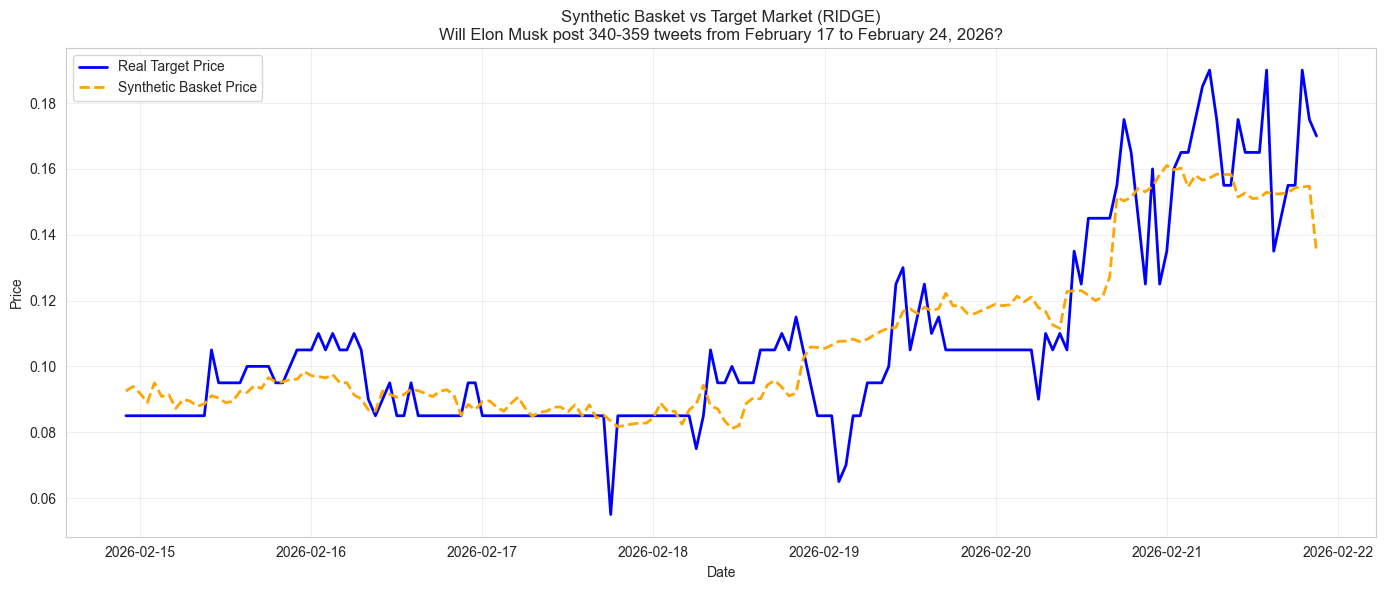

In [62]:
# Example: Build a synthetic basket for Elon Musk tweet count market

target_market_id = "1375496"  # Elon tweets 340-359 from Feb 17-24
input_market_ids = [
    "1250581",  # SpaceX IPO by March 31, 2026
    "1089018",  # Tesla Q1 2026 deliveries >= 500k
    "1370745"   # S&P 500 all-time high by March 31, 2026
]

result = build_synthetic_basket(target_market_id, market_ids, days=7)

In [63]:
# Access the results
print("\\n=== Results Summary ===")
print(f"R² Score: {result['r_squared']:.4f}")
print(f"\\nWeights array: {result['weights']}")
print(f"\\nData shape: {result['dataframe'].shape}")
print(f"\\nFirst few rows of aligned data:")
print(result['dataframe'].head())

\n=== Results Summary ===
R² Score: 0.7807
\nWeights array: [ 5.64957177e-03  4.41190326e-02 -5.34284447e-04  2.62660819e-31
  2.58085674e-02  1.35848327e-02  4.06975384e-02 -4.36063593e-03
  9.37249068e-03  1.31330409e-31 -1.00544901e-02 -2.65760313e-03
 -3.95935493e-02  1.59124608e-02 -2.90663677e-02  1.66139560e-02
  2.89552541e-02  9.46631590e-03  6.54240415e-03  2.52282214e-02
 -5.02084102e-02  1.21621261e-03 -3.22690202e-02 -1.15986224e-03
 -6.28076786e-03 -8.29623142e-03 -1.55897347e-02 -1.45607741e-02
 -2.47375703e-02  2.98721982e-02  3.06700513e-03 -1.33721602e-02
 -1.11964550e-02 -8.84595183e-02  2.62660819e-31 -7.30098385e-04
 -4.76412270e-02  1.14724957e-01 -2.05542487e-02  2.13489411e-02
 -1.40246722e-02 -2.52362299e-02]
\nData shape: (168, 44)
\nFirst few rows of aligned data:
                     Target  Grok 5 released by March 31, 2026?  \
datetime                                                          
2026-02-14 22:00:00   0.085                                0.11 

In [64]:
# Print weights in readable format with market names
print("=" * 80)
print("BASKET WEIGHTS")
print("=" * 80)

for i, (weight, market_name) in enumerate(zip(result['weights'], result['input_markets'])):
    print(f"{weight:+.6f}  | {market_name}")

print("=" * 80)
print(f"R² Score: {result['r_squared']:.6f}")
print("=" * 80)

BASKET WEIGHTS
+0.005650  | Grok 5 released by March 31, 2026?
+0.044119  | Will the chopsticks catch SpaceX Starship Flight Test 12 Superheavy booster?
-0.000534  | Will Elon register any party before 2027?
+0.000000  | Will Elon Musk announce Presidential run before 2027?
+0.025809  | Musk out as Tesla CEO before 2027?
+0.013585  | SpaceX Starship fully reusable before 2027?
+0.040698  | Will Tesla launch robotaxis in California by June 30?
-0.004361  | Will Elon Musk be richest person on March 31?
+0.009372  | Will Elon Musk be richest person on December 31?
+0.000000  | Will xAI release a dLLM by June 30?
-0.010054  | Will Elon Musk go on Joe Rogan before June 30?
-0.002658  | Will Tesla open orders for the Robovan before 2027?
-0.039594  | Elon Musk trillionaire before 2027?
+0.015912  | Will SpaceX's market cap be greater than $1T at market close on IPO day?
-0.029066  | Another Elon baby by June 30?
+0.016614  | SpaceX IPO closing market cap above $1T?
+0.028955  | Will 7-8 Spac